<a href="https://colab.research.google.com/github/comet-ctrl/open-source/blob/main/Tuning_Param_M146_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q -U datasets transformers accelerate sentence-transformers scikit-learn matplotlib peft trl bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.1/761.1 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 11.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


In [2]:
!pip uninstall -y torchao
!pip install -U torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 26.8 MB/s eta 0:00:00


In [3]:

import os
import re
import gc
import json
import math
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = Path("m146_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Device:", DEVICE)


Device: cuda


In [4]:
def clear_memory(*names):
    """Delete large variables by name and clear Python/CUDA memory."""
    for name in names:
        if name in globals():
            del globals()[name]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


In [5]:
# You may add creative instructions above the final-answer rule.
# If you do nothing, this minimal prompt still runs.
# Keep the final line parseable, or the evaluator may mark correct reasoning as wrong.
# Do not remove the boxed answer rule. Please edit the first line of the prompt and add your instructions (however long you want).
SYSTEM_PROMPT = """
Your task is to solve the math problem.

Final answer rule:
The last line of your response must be exactly:
\\boxed{ANSWER}
""".strip()


# B.1

In [6]:

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, PeftModel, TaskType
from trl import SFTTrainer, SFTConfig

MATH_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
N_EVAL = 100

gsm8k = load_dataset("openai/gsm8k", "main")
gsm8k_test_100 = gsm8k["test"].select(range(N_EVAL))

def extract_boxed(text):
    idx = text.rfind("\\boxed{")
    if idx == -1:
        return None
    start = idx + len("\\boxed{")
    depth = 1
    pos = start
    while pos < len(text) and depth > 0:
        if text[pos] == "{":
            depth += 1
        elif text[pos] == "}":
            depth -= 1
        pos += 1
    if depth != 0:
        return None
    return text[start:pos - 1]


def extract_gt(raw_answer):
    match = re.search(r"####\s*(.+)", raw_answer)
    return match.group(1).strip().replace(",", "") if match else raw_answer.strip()


def extract_model_answer(text):
    boxed = extract_boxed(text)
    if boxed is not None:
        return boxed.strip()
    nums = re.findall(r"-?\d+(?:\.\d+)?", text)
    return nums[-1] if nums else ""


def normalize_answer(ans):
    s = str(ans).strip().replace(",", "").replace("$", "").replace("%", "").replace(" ", "")
    s = re.sub(r"\\text\{([^}]*)\}", r"\1", s)
    s = re.sub(r"\\(left|right|displaystyle)", "", s)
    s = re.sub(r"\\d?frac\{([^}]+)\}\{([^}]+)\}", r"\1/\2", s)
    try:
        v = float(s)
        if math.isfinite(v):
            return str(int(v)) if v == int(v) else str(v)
    except (ValueError, OverflowError):
        pass
    if "/" in s and s.count("/") == 1:
        try:
            a, b = s.split("/")
            return f"{float(a) / float(b):.10g}"
        except (ValueError, ZeroDivisionError):
            pass
    return s


def answers_match(pred, gt):
    p, g = normalize_answer(pred), normalize_answer(gt)
    if p == g:
        return True
    try:
        return abs(float(p) - float(g)) < 1e-6
    except (ValueError, TypeError):
        return False


def load_math_model(model_name=MATH_MODEL, lora_path=None):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map="auto",
        attn_implementation="eager",
    )
    if lora_path:
        model = PeftModel.from_pretrained(model, lora_path)
    model.eval()
    return model, tokenizer


def make_gsm_prompts(tokenizer, questions, system_prompt=SYSTEM_PROMPT, few_shot_messages=None):
    prompts = []
    for q in questions:
        messages = [{"role": "system", "content": system_prompt}]
        if few_shot_messages:
            messages.extend(few_shot_messages)
        messages.append({"role": "user", "content": q})
        prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))
    return prompts


def generate_math(model, tokenizer, questions, system_prompt=SYSTEM_PROMPT, few_shot_messages=None, batch_size=16, max_new_tokens=512):
    responses = []
    for start in range(0, len(questions), batch_size):
        batch_questions = questions[start:start + batch_size]
        prompts = make_gsm_prompts(tokenizer, batch_questions, system_prompt=system_prompt, few_shot_messages=few_shot_messages)
        inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True).to(model.device)
        prompt_len = inputs["input_ids"].shape[1]
        with torch.no_grad():
            out = model.generate(**inputs, do_sample=False, max_new_tokens=max_new_tokens)
        for i in range(len(batch_questions)):
            responses.append(tokenizer.decode(out[i][prompt_len:], skip_special_tokens=True).strip())
    return responses


def evaluate_gsm8k(model, tokenizer, split, num_samples=100, system_prompt=SYSTEM_PROMPT, few_shot_messages=None, batch_size=16, output_name=None):
    n = min(num_samples, len(split))
    records = []
    correct = 0
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        questions = [split[i]["question"] for i in range(start, end)]
        gts = [extract_gt(split[i]["answer"]) for i in range(start, end)]
        responses = generate_math(model, tokenizer, questions, system_prompt=system_prompt, few_shot_messages=few_shot_messages, batch_size=batch_size)
        for offset, (q, gt, resp) in enumerate(zip(questions, gts, responses)):
            pred = extract_model_answer(resp)
            ok = answers_match(pred, gt)
            correct += int(ok)
            records.append({
                "index": start + offset,
                "question": q,
                "ground_truth": gt,
                "model_response": resp,
                "extracted_answer": pred,
                "correct": ok,
            })
    result = {"accuracy": correct / n, "correct": correct, "total": n, "records": records}
    if output_name:
        path = OUTPUT_DIR / output_name
        path.write_text(json.dumps(result, indent=2))
    return result


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

In [7]:
clear_memory("base_model", "base_tokenizer", "base_result")

base_model, base_tokenizer = load_math_model()

base_result = evaluate_gsm8k(
    model = base_model,
    tokenizer = base_tokenizer,
    split = gsm8k_test_100,
    num_samples = N_EVAL,
    system_prompt = SYSTEM_PROMPT,
    few_shot_messages = None,
    batch_size = 16,
    output_name = "b1_base_qwen_100_gsm8k.json"
)

print(f"Model: {MATH_MODEL}")
print(f"Number of questions: {base_result['total']}")
print(f"Correct: {base_result['correct']}")
print(f"Accuracy: {base_result['accuracy']:.2%}")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model: Qwen/Qwen2.5-1.5B-Instruct
Number of questions: 100
Correct: 36
Accuracy: 36.00%


# B.2

In [8]:
incorrect_records = [r for r in base_result["records"] if not r["correct"]]

for i, record in enumerate(incorrect_records[:3], start = 1):
    print(f"Question {i}:")
    print(record["question"])
    print()
    print("Model response:")
    print(record["model_response"])
    print()
    print("Extracted answer")
    print(record["extracted_answer"])
    print()
    print("Ground-truth answer:")
    print(record["ground_truth"])
    print()

Question 1:
Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?

Model response:
To determine Josh's profit from flipping the house, we need to follow these steps:

1. Calculate the total cost of buying and repairing the house.
2. Determine the new value of the house after the repairs.
3. Find out how much more money the house is worth than what it originally cost.
4. Subtract the original cost from this amount to find the profit.

Let's go through each step in detail:

### Step 1: Total Cost Calculation
- Initial purchase price of the house: $80,000
- Amount spent on repairs: $50,000

Total cost = Purchase price + Repair costs
\[ \text{Total cost} = \$80,000 + \$50,000 = \$130,000 \]

### Step 2: New Value After Repairs
The problem states that the repairs increased the value of the house by 150%.

New value = Original value + (Original value * Percentage in

Problem 1: The failure mode is misunderstanding the problem. The model thinks that "increased the valued by 150%) is a 15% increase, but it should be 150%. This causes the model to multiply by a factor of 0.15 instead of 1.5, leading to the incorrect answer.

Problem 2: There are two failure modes, arithmetic slip and misunderstanding the problem. The model makes an arithmetic error with "15 + 25 = 4" instead of getting 40, and the question asks how many cups Wendi needs to give her chickens in total, but the model misunderstoods it as cups per chicken, which leads to an extra division.

Problem 3: There are also two failure modes, logical error and misunderstanding the problem.  The model ignores the 20 minutes that is required for the restart and does not include it in the calcuation, and it misunderstands the"restart the download from the beginning" part of the problem and interprets it as "continuing from where it left".

The recurring pattern is that the model often misunderstands the conditions of the problem, which requires a general view of the entire problem statement rather than just looking at parts of it.

# B.3

In [9]:

LORA_DEFAULTS = {
    "rank": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.05,
    "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj"],
    "learning_rate": 2e-4,
    "epochs": 1,
    "batch_size": 4,
    "grad_accum": 8,
    "max_seq_len": 1024,
}


def build_lora_config():
    return LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=LORA_DEFAULTS["rank"],
        lora_alpha=LORA_DEFAULTS["lora_alpha"],
        lora_dropout=LORA_DEFAULTS["lora_dropout"],
        target_modules=LORA_DEFAULTS["target_modules"],
        bias="none",
    )


def format_gsm8k_train_example(example):
    reasoning = example["answer"].split("####")[0].strip()
    final = extract_gt(example["answer"])
    assistant = f"{reasoning}\n\n\\boxed{{{final}}}"
    return {
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": example["question"]},
            {"role": "assistant", "content": assistant},
        ]
    }


def train_lora_sft(num_samples, output_dir, model_name=MATH_MODEL):
    output_dir = Path(output_dir)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.padding_side = "right"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map="auto",
        attn_implementation="eager",
    )
    model = get_peft_model(model, build_lora_config())
    model.print_trainable_parameters()

    train_data = gsm8k["train"].select(range(min(num_samples, len(gsm8k["train"]))))
    train_data = train_data.map(format_gsm8k_train_example, remove_columns=train_data.column_names)

    args = SFTConfig(
        output_dir=str(output_dir),
        num_train_epochs=LORA_DEFAULTS["epochs"],
        per_device_train_batch_size=LORA_DEFAULTS["batch_size"],
        gradient_accumulation_steps=LORA_DEFAULTS["grad_accum"],
        learning_rate=LORA_DEFAULTS["learning_rate"],
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        bf16=torch.cuda.is_available(),
        logging_steps=10,
        save_strategy="epoch",
        save_total_limit=1,
        report_to="none",
        max_length=LORA_DEFAULTS["max_seq_len"],
        completion_only_loss=True,
    )
    trainer = SFTTrainer(model=model, args=args, train_dataset=train_data, processing_class=tokenizer)
    trainer.train()

    adapter_path = output_dir / "final_adapter"
    model.save_pretrained(adapter_path)
    tokenizer.save_pretrained(adapter_path)
    return str(adapter_path)


For LoRA rank, it controls the capacity of the LoRA adapter. Since LoRA represents the update to a weight matrix using two low-rank matrices, the rank determines how expressive that update can be. If we increase the rank, the model has more trainable parameters and can learn more complicated changes for GSM8K reasoning. This may improve accuracy, especially if the original rank is too small. However, it also increases GPU memory use, training time, and the risk of overfitting. If we decrease the rank, training becomes cheaper and more memory-efficient, but the adapter may not have enough capacity to learn the reasoning patterns, so the model may underfit.

For LoRA alpha, it controls the strength of the LoRA update. The LoRA update is usually scaled by alpha divided by the rank, so alpha decides how strongly the adapter changes the frozen base model’s behavior. If we increase alpha, the fine-tuned adapter has a stronger effect, which can help the model adapt faster to the dataset like GSM8K. But if alpha is too large, training may become unstable, and the adapter may overpower the base model’s original knowledge, causing worse generalization. If we decrease alpha, the adapter affects the base model more gently, which can improve stability and preserve the original model. But if alpha is too small, the model may not learn enough from the training examples, again underfitting.

For gradient accumulation, it controls the effective batch size. Instead of updating the model after every small batch, we accumulate gradients over several batches and then make one optimizer update. For example, with per-device batch size 8 and gradient accumulation 4, the effective batch size is 32. If we increase gradient accumulation, the effective batch size becomes larger, so the gradients are usually smoother and training can be more stable. This is useful when GPU memory is limited. However, each optimizer update takes longer, and there are fewer updates per epoch, so training may become slower or less responsive. If we decrease gradient accumulation, the effective batch size becomes smaller, giving more frequent updates, but the gradients become noisier and training may become less stable.

# B.4

In [10]:
clear_memory("lora_model")

base_total_params = sum(p.numel() for p in base_model.parameters())

lora_model = get_peft_model(base_model, build_lora_config())

trainable_lora_params = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)

percent_trainable = 100 * trainable_lora_params / base_total_params

print(f"(a) Total parameters in the base model: {base_total_params:,}")
print(f"(b) Trainable LoRA parameters: {trainable_lora_params:,}")
print(f"(c) Percentage of parameters being trained: {percent_trainable:.4f}%")

#Could also use lora_model.print_trainable_parameters()

(a) Total parameters in the base model: 1,543,714,304
(b) Trainable LoRA parameters: 2,179,072
(c) Percentage of parameters being trained: 0.1412%


This percentage is very small because LoRA only trains the small adapter matrices that is later added to the weights. LoRA represents the update using two low-rank matrices A, B with LoRA rank r that is much smaller than the base model dimension. Thus the number of trainable parameters is tiny compared to the total.

# B.5

In [11]:
clear_memory("base_model", "base_tokenizer", "lora_model", "lora_1k_model", "lora_1k_tokenizer", "lora_1k_result")

#Note: Due to CUDA out of memory, we change batch_size = 4 and gradient_accumulation = 8
lora_1k_path = train_lora_sft(num_samples = 1000, output_dir=OUTPUT_DIR / "lora_gsm8k_1k")
print(f"LoRA adapter saved to: {lora_1k_path}")

clear_memory()

lora_1k_model, lora_1k_tokenizer = load_math_model(lora_path = lora_1k_path)

lora_1k_result  = evaluate_gsm8k(
    model = lora_1k_model,
    tokenizer = lora_1k_tokenizer,
    split = gsm8k_test_100,
    output_name = "b5_lora_1k_qwen_100_gsm8k.json"
)

print(f"Model: {MATH_MODEL} + LoRA 1k adapter")
print(f"Number of questions: {lora_1k_result['total']}")
print(f"Correct: {lora_1k_result['correct']}")
print(f"Accuracy: {lora_1k_result['accuracy']:.2%}")


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Tokenizing train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,1.173051
20,0.684844
30,0.485964


LoRA adapter saved to: m146_outputs/lora_gsm8k_1k/final_adapter


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model: Qwen/Qwen2.5-1.5B-Instruct + LoRA 1k adapter
Number of questions: 100
Correct: 41
Accuracy: 41.00%


The 5% increase in accuracy over the baseline matched my expectation, as the model is exposed to modified GSM8K solutions with training examples formatted to match the desired output. The LoRA adapter trains only a small fraction of the parameters, which explains the moderate improvement.

#B.6

I think scaling from 1,000 examples to 2,000 examples is worth the additional compute as the additional problems expose the model to more problem types, which allows to it generalize better when solving the test problems that it has not seen before.

I expect the 2k model to have accuracy around 45%, which is less accuracy increase than the first jump from the base model to the 1k LoRA model. This is because I expect the model to have some accuracy increase in the first 1k examples, and diminished accuracy due to the limited amount of problem varieties that the second 1k can provide.


# B.7

In [12]:
# We modify the hyperparameters here for better model fitting
LORA_DEFAULTS["rank"] = 16
LORA_DEFAULTS["lora_alpha"] = 32
LORA_DEFAULTS["epochs"] = 2
LORA_DEFAULTS["learning_rate"] = 1e-4

In [13]:
clear_memory("base_model", "base_tokenizer", "lora_model", "lora_1k_model", "lora_1k_tokenizer","lora_2k_model","lora_2k_tokenizer","lora_2k_result")

lora_2k_path = train_lora_sft(num_samples = 2000, output_dir=OUTPUT_DIR / "lora_gsm8k_2k")
print(f"LoRA adapter saved to: {lora_2k_path}")

clear_memory()

lora_2k_model, lora_2k_tokenizer = load_math_model(lora_path = lora_2k_path)

lora_2k_result  = evaluate_gsm8k(
    model = lora_2k_model,
    tokenizer = lora_2k_tokenizer,
    split = gsm8k_test_100,
    output_name = "b7_lora_2k_qwen_100_gsm8k.json"
)

print(f"Model: {MATH_MODEL} + LoRA 2k adapter")
print(f"Number of questions: {lora_2k_result['total']}")
print(f"Correct: {lora_2k_result['correct']}")
print(f"Accuracy: {lora_2k_result['accuracy']:.2%}")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 4,358,144 || all params: 1,548,072,448 || trainable%: 0.2815


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Tokenizing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,1.288999
20,0.798695
30,0.484829
40,0.389450
50,0.317455
60,0.291951
70,0.273634
80,0.282521
90,0.273257
100,0.279193


LoRA adapter saved to: m146_outputs/lora_gsm8k_2k/final_adapter


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model: Qwen/Qwen2.5-1.5B-Instruct + LoRA 2k adapter
Number of questions: 100
Correct: 44
Accuracy: 44.00%


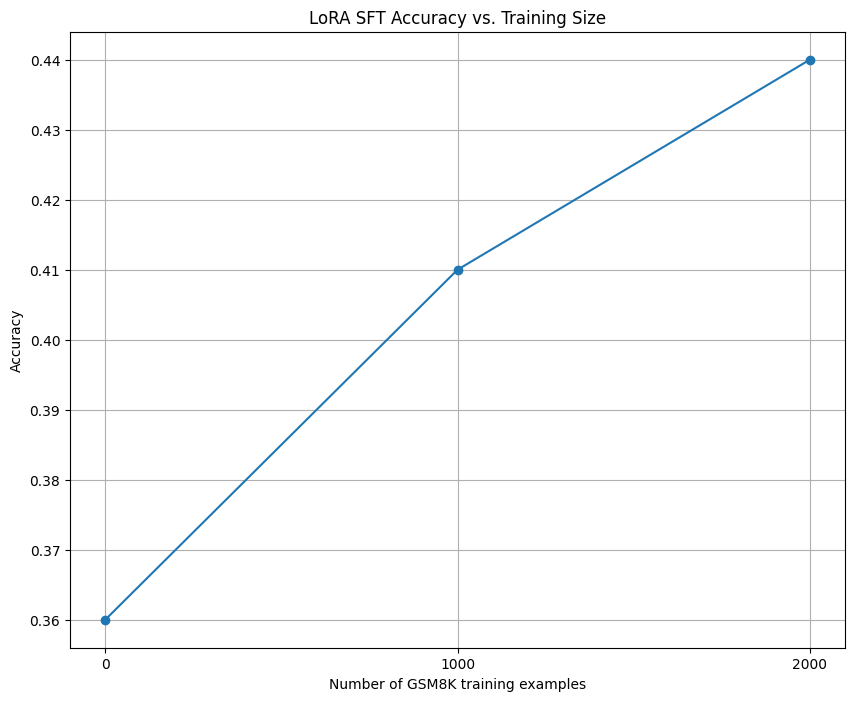

In [14]:
train_sizes = [0, 1000, 2000]
accuracies = [
    base_result["accuracy"],
    lora_1k_result["accuracy"],
    lora_2k_result["accuracy"]
]

plt.figure(figsize = (10, 8))
plt.plot(train_sizes, accuracies, marker = "o")
plt.xlabel("Number of GSM8K training examples")
plt.ylabel("Accuracy")
plt.title("LoRA SFT Accuracy vs. Training Size")
plt.xticks(train_sizes)
plt.grid(True)
plt.show()

The plot displays the improvement from 0 to 1k examples was 5 percentage points, and the improvement from 1k to 2k examples was 3 percentage points, which indicates the diminishing returns. The second 1k examples gave a smaller increase in accuracy than the first, which is reasonable since the model may learn the basic question and answer style from the first 1k example, but further improvements in accuracy and reasoning may be harder from just another 1k examples. Therefore, LoRA SFt improves performance but does not completely solve the accuracy problem.

# B.8

In [22]:
failure_index = [r["index"] for r in incorrect_records[:3]]
base_records_index = {r["index"]: r for r in base_result["records"]}
sft_records_index = {r["index"]: r for r in lora_2k_result["records"]}

for num, idx in enumerate(failure_index, start = 1):
    base_record = base_records_index[idx]
    sft_record = sft_records_index[idx]
    print(f"Question {num}:")
    print()
    print(base_record["question"])
    print("Ground-truth answer:")
    print(base_record["ground_truth"])
    print()
    print("Base Model response:")
    print(base_record["model_response"])
    print()
    print("Extracted answer")
    print(base_record["extracted_answer"])
    print()
    print("SFT Model response:")
    print(sft_record["model_response"])
    print()
    print("Extracted answer")
    print(sft_record["extracted_answer"])
    print()



Question 1:

Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?
Ground-truth answer:
70000

Base Model response:
To determine Josh's profit from flipping the house, we need to follow these steps:

1. Calculate the total cost of buying and repairing the house.
2. Determine the new value of the house after the repairs.
3. Find out how much more money the house is worth than what it originally cost.
4. Subtract the original cost from this amount to find the profit.

Let's go through each step in detail:

### Step 1: Total Cost Calculation
- Initial purchase price of the house: $80,000
- Amount spent on repairs: $50,000

Total cost = Purchase price + Repair costs
\[ \text{Total cost} = \$80,000 + \$50,000 = \$130,000 \]

### Step 2: New Value After Repairs
The problem states that the repairs increased the value of the house by 150%.

New value = Original value 

The SFT model fixes Question 2. While the base model struggles with arithmetic mistake: 15 + 25 = 4 and incorrectly answered a per-chicken amount, the SFT model correctly computes the required amount in clear logical flow and puts the final answer in required form.

#B.9

Looking at question 1 and 3 from B.8. For question 1, the SFT model still fails to intrepret thhe 150% increase in value and made up a multiple of .75. Despite being correct in calculation, the misunderstanding causes the model to produce an incorrect answer.

For question 3, the SFT model recognizes the restart-time but decided to compute a new one which is not included in the problem. The model again misunderstands how the restart-time is supposed to work and produces an incorrect answer.

Therefore, the model still struggles with problem comprehension, but it is much better at arithmetic computation and multi-step reasoning.

#B.10

In [15]:
def few_shot_messages_from_train(train_split, indices=(0, 1, 2)):
    messages = []
    for idx in indices:
        ex = train_split[int(idx)]
        reasoning = ex["answer"].split("####")[0].strip()
        final = extract_gt(ex["answer"])
        messages.append({"role": "user", "content": ex["question"]})
        messages.append({"role": "assistant", "content": f"{reasoning}\n\n\\boxed{{{final}}}"})
    return messages

In [16]:
few_shot_messages = few_shot_messages_from_train(gsm8k["train"], indices=(0, 1, 2))

clear_memory("base_model", "base_tokenizer", "lora_model", "lora_1k_model", "lora_1k_tokenizer","lora_2k_model","lora_2k_tokenizer")

base_model, base_tokenizer = load_math_model()

base_3shot_result = evaluate_gsm8k(
    model = base_model,
    tokenizer = base_tokenizer,
    split = gsm8k_test_100,
    system_prompt = SYSTEM_PROMPT,
    few_shot_messages = few_shot_messages,
    output_name = "b10_base_3shot_gsm8k100.json"
)

print(f"Model: {MATH_MODEL}")
print(f"Number of questions: {base_3shot_result['total']}")
print(f"Correct: {base_3shot_result['correct']}")
print(f"Accuracy: {base_3shot_result['accuracy']}")

lora_2k_model, lora_2k_tokenizer = load_math_model(lora_path = lora_2k_path)

lora_2k_3shot_result = evaluate_gsm8k(
    model = lora_2k_model,
    tokenizer = lora_2k_tokenizer,
    split = gsm8k_test_100,
    system_prompt = SYSTEM_PROMPT,
    few_shot_messages = few_shot_messages,
    output_name = "b10_lora_2k_3shot_gsm8k100.json"
)

print(f"Model: {MATH_MODEL} + LoRA 2k adapter")
print(f"Number of questions: {lora_2k_3shot_result['total']}")
print(f"Correct: {lora_2k_3shot_result['correct']}")
print(f"Accuracy: {lora_2k_3shot_result['accuracy']:.2%}")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model: Qwen/Qwen2.5-1.5B-Instruct
Number of questions: 100
Correct: 34
Accuracy: 0.34


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model: Qwen/Qwen2.5-1.5B-Instruct + LoRA 2k adapter
Number of questions: 100
Correct: 47
Accuracy: 47.00%


In [17]:
fewshot_result = pd.DataFrame([
    {
        "model": "base",
        "no-demonstration baseline accuracy": base_result["accuracy"],
        "3-shot baseline accuracy": base_3shot_result["accuracy"],
        "improvement": base_3shot_result["accuracy"] - base_result["accuracy"],
    },
    {
        "model": "LoRA 2k adapter",
        "no-demonstration baseline accuracy": lora_2k_result["accuracy"],
        "3-shot baseline accuracy": lora_2k_3shot_result["accuracy"],
        "improvement": lora_2k_3shot_result["accuracy"] - lora_2k_result["accuracy"],
    },
])

display(fewshot_result)



,model,no-demonstration baseline accuracy,3-shot baseline accuracy,improvement
0,base,0.36,0.34,-0.02
1,LoRA 2k adapter,0.44,0.47,0.03


# B.11

Few-shot does not help the base model. The base model accuracy decreased by 2 percentage points. One possible reason it performs worse with demonstrations is because the few-shot prompts made the prompt longer and more complex, which might be too much instruction for the model to handle and caused it to imitate rather than provide reasoning.

Few-shot does help the SFT model. The SFT model accuracy increased by 3 percentage points. This indicates that after fine-tuning, the model was able to use the xamples as guidance when solving other problems and perhaps formatting the final answer. Overall, the LoRA 2k model benefitteed more from the few-shot prompting than the base model.

# B.12

In [18]:
# Keep PROMPT_0 as the old prompt. Fill in PROMPT_1, PROMPT_2, PROMPT_3 yourself.
PROMPT_0 = SYSTEM_PROMPT

PROMPT_1 = """
You are a world-class International Mathematical Olympiad (IMO) competitor.
Your goal is to find the correct answer through rigorous mathematical reasoning.

Problem-Solving Approach:
1. UNDERSTAND: Carefully read and rephrase the problem in your own words. Identify what is give what needs to be found, and any constraints.
2. PLAN: Select the most promising approach and outline key steps before executing.
3. EXECUTE: Work through your solution methodically. Show all reasoning steps clearly.
4. VERIFY: Check your answer by substituting back, testing edge cases, or using alternative methods. Ensure logical consistency throughout.

Final answer rule:
The last line of your response must be exactly:
\boxed{ANSWER}
""".strip()

PROMPT_2 = """
You are an eighth grade math teacher. Your task is to solve the math problem correctly, keeping the reasoning clear and concise..
1. First identify exactly what quantity the problem is asking for.
2. List the given information that is needed to solve the problem.
3. Perform the calculations step by step in order.
4. Check that the final number answers the original question.

Final answer rule:
The last line of your response must be exactly:
\boxed{ANSWER}
""".strip()

PROMPT_3 = """
You are an elite mathematical problem solver operating at IMO medalist level.
1. Precisely interpret the problem and identify constraints.
2. Consider multiple strategies before selecting the most efficient
3. Execute with strict logical validity and clean algebra.
4. Verify via substitution, edge cases, or alternate reasoning.
5. Reject results that violate constraints or produce inconsistencies.
6. If stuck, reframe or work backwards

Accept an answer ONLY if:
- all constraints are satisfied
- computations are internally consistent

Final answer rule:
The last line of your response must be exactly:
\boxed{ANSWER}
""".strip()

PROMPT_4 = """
You are a careful math assistant. Solve the problem with clear reasoning and give the final answer in the required format.

Final answer rule:
The last line of your response must be exactly:
\boxed{ANSWER}
""".strip()

PROMPT_5 = """
Final answer rule:
The last line of your response must be exactly:
\boxed{ANSWER}
""".strip()


def evaluate_one_prompt(model, tokenizer, prompt, name="prompt", n=50):
    result = evaluate_gsm8k(
        model,
        tokenizer,
        gsm8k["test"].select(range(n)),
        num_samples=n,
        system_prompt=prompt,
        batch_size=16,
    )
    return {"prompt_name": name, "accuracy": result["accuracy"], "correct": result["correct"], "total": result["total"]}, result

# Baseline bonus run using the old prompt. After this, run your own prompt variants.
if "math_model" not in globals() or "math_tokenizer" not in globals():
    math_model, math_tokenizer = load_math_model()

baseline_row, baseline_result = evaluate_one_prompt(math_model, math_tokenizer, PROMPT_0, name="old_prompt")
baseline_row


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

{'prompt_name': 'old_prompt', 'accuracy': 0.32, 'correct': 16, 'total': 50}

In [19]:
prompt_row, prompt_result = [], {}

for name, prompt in [
    ("prompt_1", PROMPT_1),
    ("prompt_2", PROMPT_2),
    ("prompt_3", PROMPT_3),
    ("prompt_4", PROMPT_4),
    ("prompt_5", PROMPT_5),
]:
    row, result = evaluate_one_prompt(math_model, math_tokenizer, prompt, name=name)
    prompt_row.append(row)
    prompt_result[name] = result

prompt_df = pd.DataFrame(prompt_row)
display(prompt_df)


,prompt_name,accuracy,correct,total
0,prompt_1,0.32,16,50
1,prompt_2,0.30,15,50
2,prompt_3,0.30,15,50
3,prompt_4,0.40,20,50
4,prompt_5,0.26,13,50


For the 5 prompt variants, prompt 4 achieved the best accuracy of 40% overall. Prompt 4 is a single-direct prompt that asked the model to solve the problem in clear reasoning.

For prompt 1 to 3, I implemented complicated instructions and roles that asked the model to use rigorous steps and even multiple solutions. I think such prompts are too complicated for the base model and the GSM8k questions which either does not have the ability nor do not require such advanced mathematical reasoning. The extra instructions likely distracted the model from just simply solving the problems, which is reflected by the 30% average accuracy across the 3 prompts.

Prompt 5 performed the worst with only 26% accuracy. However, this is reasonable as it only enforced the final boxed-answer rule. I wanted to see how far the model could get without any instructions. It turns out that only output formatting is not enough and simple instructions are necessary.

Therefore, as the best result do come from a short, clear prompt, for small models like Qwen2.5-1.5B, simple instructions may matter more than complex reasoning or role-based prompting.